# Принятие решений в бизнесе

# Описание исследования

В нашем распоряжении список гипотез для увеличения выручки интернет магазина и результаты A/B тестов в виде данных о заказах пользователей и данных об их посещениях.

# Цель исследования

Приоритизировать гипотезы и проанализировать результаты A/B-теста.

# Задачи исследования

1. Оценить представленные данные.
2. Выполнить предобработку данных.
3. Приоритизирровать гипотезы.
4. Провести исследовательский анализ данных.
5. Проанализировать результаты A/B-теста.

# Исходные данные

В нашем распоряжении три датасета. Файл hypothesis.csv, который содежит 9 гипотез по увеличению выручки интернет-магазина с указанными параметрами Reach, Impact, Confidence, Effort. Файл orders.csv хранит данные о заказах пользователей интернет магазина. Файл visitors.csv хранит данные о посещения пользователей интернет магазина.

Структура hypothesis.csv:

    Hypothesis — краткое описание гипотезы;
    Reach — охват пользователей по 10-балльной шкале;
    Impact — влияние на пользователей по 10-балльной шкале;
    Confidence — уверенность в гипотезе по 10-балльной шкале;
    Efforts — затраты ресурсов на проверку гипотезы по 10-балльной шкале. Чем больше значение Efforts, тем дороже проверка гипотезы.

Структура orders.csv:

    transactionId — идентификатор заказа;
    visitorId — идентификатор пользователя, совершившего заказ;
    date — дата, когда был совершён заказ;
    revenue — выручка заказа;
    group — группа A/B-теста, в которую попал заказ.

Структура visitors.csv:

    date — дата;
    group — группа A/B-теста;
    visitors — количество пользователей в указанную дату в указанной группе A/B-теста

# Данное исследование разделим на несколько частей

## Загрузим данные и подготовим их к анализу

### Импортируем необходимые библиотеки

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from matplotlib import pyplot as plt
import matplotlib.dates as mdates
from matplotlib.dates import DateFormatter
from matplotlib.ticker import MultipleLocator
import seaborn as sns
import matplotlib.ticker as ticker
import plotly.express as px
from plotly import graph_objects as go
from scipy import stats as st
import scipy.stats as stats
import warnings

### Cчитаем данные из csv-файла в датафрейм и сохраним в переменные hypothesis, orders и visitors

In [2]:
hypothesis = pd.read_csv(r'C:\Users\Равиль\Проекты для портфолио\8. Проект принятие решений в бизнесе\hypothesis.csv')
orders = pd.read_csv(r'C:\Users\Равиль\Проекты для портфолио\8. Проект принятие решений в бизнесе\orders.csv')
visitors = pd.read_csv(r'C:\Users\Равиль\Проекты для портфолио\8. Проект принятие решений в бизнесе\visitors.csv')

### Изучим общую информацию о датафрейме hypothesis

In [3]:
pd.set_option('display.max_colwidth', None)
display(hypothesis.head(10))

,Hypothesis,Reach,Impact,Confidence,Efforts
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",3,10,8,6
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2,5,4,10
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",8,3,7,3
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",8,3,3,8
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3,1,1,1
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",3,2,2,3
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",5,3,8,3
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",10,7,8,5
8,"Запустить акцию, дающую скидку на товар в день рождения",1,9,9,5


### Изучим общую информацию о датафрейме orders

In [4]:
orders.head(10)

,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,1650,B
1,2804400009,3642806036,2019-08-15,730,B
2,2961555356,4069496402,2019-08-15,400,A
3,3797467345,1196621759,2019-08-15,9759,B
4,2282983706,2322279887,2019-08-15,2308,B
5,182168103,935554773,2019-08-15,2210,B
6,398296753,2900797465,2019-08-15,1860,B
7,2626614568,78758296,2019-08-15,1044,A
8,1576988021,295230930,2019-08-15,13710,A
9,1506739906,1882260405,2019-08-15,1855,B


### Оценим какие минимальные и максимальные даты совершения заказов присутствуют в датафрейме orders

In [5]:
orders[['date']].agg(['min', 'max'])

,date
min,2019-08-01
max,2019-08-31


### Изучим общую информацию о датафрейме visitors

In [6]:
visitors.head(10)

,date,group,visitors
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756
5,2019-08-06,A,667
6,2019-08-07,A,644
7,2019-08-08,A,610
8,2019-08-09,A,617
9,2019-08-10,A,406


### Оценим какие минимальные и максимальные даты посещения интернет магазина присутствуют в датафрейме visitors

In [7]:
visitors[['date']].agg(['min', 'max'])

,date
min,2019-08-01
max,2019-08-31


### Выведем основную информацию о датафреймах hypothesis, orders и visitors

In [8]:
hypothesis.info()
print()
orders.info()
print()
visitors.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Efforts     9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 488.0+ bytes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   transactionId  1197 non-null   int64 
 1   visitorId      1197 non-null   int64 
 2   date           1197 non-null   object
 3   revenue        1197 non-null   int64 
 4   group          1197 non-null   object
dtypes: int64(3), object(2)
memory usage: 46.9+ KB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 # 

### Выводы по первому разделу

Таблица hypothesis содежит 5 столбцов в которой имеются целые числа и строки. Таблица orders содержит 5 столбцов в которой имеются целые, вещественны числа и строки. Диапазон дат совершения заказов находится в пределах 01.08.2019 - 31.08.2019. Таблица visitors содержит 3 столбца в которой имеются целые числа и строки. Диапазон дат посещения интернет магазина посетителями находится в пределах 01.08.2019 - 31.08.2019. Названия столбцов hypothesis начинаются заглавных букв, а названия столбцов таблицы orders содержит заглавные буквы. Имеет смысл перевести их в нижний регистр. Также столбцы date в таблицах orders и visitors имеют тип строки. Имеет смысл первести их в тип даты для последующего анализа данных.

## Предобработка данных

### Приведем к нижнему регистру названия столбцов датафрейма hypothesis и оценим результат

In [9]:
hypothesis.columns = ['hypothesis', 'reach', 'impact', 'confidence', 'efforts']
hypothesis.head()

,hypothesis,reach,impact,confidence,efforts
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",3,10,8,6
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2,5,4,10
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",8,3,7,3
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",8,3,3,8
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3,1,1,1


### Приведем к нижнему регистру названия столбцов датафрейма orders и оценим результат

In [10]:
orders.columns = ['transactionid', 'visitorid', 'date', 'revenue', 'group']
orders.head()

,transactionid,visitorid,date,revenue,group
0,3667963787,3312258926,2019-08-15,1650,B
1,2804400009,3642806036,2019-08-15,730,B
2,2961555356,4069496402,2019-08-15,400,A
3,3797467345,1196621759,2019-08-15,9759,B
4,2282983706,2322279887,2019-08-15,2308,B


### Сменим тип данных столбца date датафрейма orders с object на datetime и оценим результат смены

In [11]:
orders['date'] = pd.to_datetime(orders['date'])
print(orders.info())
orders.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   transactionid  1197 non-null   int64         
 1   visitorid      1197 non-null   int64         
 2   date           1197 non-null   datetime64[ns]
 3   revenue        1197 non-null   int64         
 4   group          1197 non-null   object        
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 46.9+ KB
None


,transactionid,visitorid,date,revenue,group
0,3667963787,3312258926,2019-08-15,1650,B
1,2804400009,3642806036,2019-08-15,730,B
2,2961555356,4069496402,2019-08-15,400,A
3,3797467345,1196621759,2019-08-15,9759,B
4,2282983706,2322279887,2019-08-15,2308,B


### Сменим тип данных столбца date датафрейма visitors с object на datetime и оценим результат смены

In [12]:
visitors['date'] = pd.to_datetime(visitors['date'])
print(visitors.info())
visitors.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      62 non-null     datetime64[ns]
 1   group     62 non-null     object        
 2   visitors  62 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.6+ KB
None


,date,group,visitors
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


### Опеределим сколько всего есть пропущенных значений в датафреймах hypothesis, orders и visitors

In [13]:
print(hypothesis.isna().sum().sort_values(ascending=False))
print()
print(orders.isna().sum().sort_values(ascending=False))
print()
print(visitors.isna().sum().sort_values(ascending=False))

hypothesis    0
reach         0
impact        0
confidence    0
efforts       0
dtype: int64

transactionid    0
visitorid        0
date             0
revenue          0
group            0
dtype: int64

date        0
group       0
visitors    0
dtype: int64


### Проверим есть ли явные дубликаты в датафреймах hypothesis, orders и visitors

In [14]:
print(hypothesis.duplicated().sum())
print()
print(orders.duplicated().sum())
print()
print(visitors.duplicated().sum())

0

0

0


### Сменим тип данных столбца date датафрейма orders с object на datetime и оценим результат смены

In [15]:
orders['date'] = pd.to_datetime(orders['date'])
print(orders.info())
orders.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   transactionid  1197 non-null   int64         
 1   visitorid      1197 non-null   int64         
 2   date           1197 non-null   datetime64[ns]
 3   revenue        1197 non-null   int64         
 4   group          1197 non-null   object        
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 46.9+ KB
None


,transactionid,visitorid,date,revenue,group
0,3667963787,3312258926,2019-08-15,1650,B
1,2804400009,3642806036,2019-08-15,730,B
2,2961555356,4069496402,2019-08-15,400,A
3,3797467345,1196621759,2019-08-15,9759,B
4,2282983706,2322279887,2019-08-15,2308,B
5,182168103,935554773,2019-08-15,2210,B
6,398296753,2900797465,2019-08-15,1860,B
7,2626614568,78758296,2019-08-15,1044,A
8,1576988021,295230930,2019-08-15,13710,A
9,1506739906,1882260405,2019-08-15,1855,B


### Запишем общее количество строк в изначальном датафрейме orders

In [16]:
count_rows_orders = len(orders)
count_rows_orders

1197

### Оценим сколько уникальных групп тестирования и их количество есть в датафрейме orders

In [17]:
print(orders['group'].unique())
print(orders['group'].nunique())

['B' 'A']
2


### Оценим сколько уникальных пользователей есть в группе A и B

In [18]:
unique_visitors_by_group = orders.groupby('group')['visitorid'].nunique()
unique_visitors_by_group

group
A    503
B    586
Name: visitorid, dtype: int64

### Определим группу для каждого уникального пользователя

In [19]:
user_groups = orders.groupby('visitorid')['group'].unique()
user_groups.head(15)

visitorid
5114589        [B]
6958315        [B]
8300375     [B, A]
11685486       [A]
39475350       [B]
47206413       [B]
48147722       [B]
54447517       [A]
56960363       [B]
66685450       [A]
71018815       [B]
78678012       [B]
78758296       [A]
85103373       [A]
87885904       [A]
Name: group, dtype: object

### Проверим есть ли пользователи, которые присутствуют в обеих группах тестирования

In [20]:
users_in_both_groups = user_groups[user_groups.apply(lambda x: len(x) > 1)].index
users_in_both_groups

Int64Index([   8300375,  199603092,  232979603,  237748145,  276558944,
             351125977,  393266494,  457167155,  471551937,  477780734,
             818047933,  963407295, 1230306981, 1294878855, 1316129916,
            1333886533, 1404934699, 1602967004, 1614305549, 1648269707,
            1668030113, 1738359350, 1801183820, 1959144690, 2038680547,
            2044997962, 2378935119, 2458001652, 2579882178, 2587333274,
            2600415354, 2654030115, 2686716486, 2712142231, 2716752286,
            2780786433, 2927087541, 2949041841, 2954449915, 3062433592,
            3202540741, 3234906277, 3656415546, 3717692402, 3766097110,
            3803269165, 3891541246, 3941795274, 3951559397, 3957174400,
            3963646447, 3972127743, 3984495233, 4069496402, 4120364173,
            4186807279, 4256040402, 4266935830],
           dtype='int64', name='visitorid')

In [21]:
users_in_both_groups_count = len(users_in_both_groups)
users_in_both_groups_count

58

### Удалим из датафрейма orders строки пользователями, которые присутствуют в обеих группах тестирования

In [22]:
orders = orders[~orders['visitorid'].isin(users_in_both_groups)]

### Запишем общее количество строк в датафрейме orders после удаления

In [23]:
count_rows_orders_after_del = len(orders)
count_rows_orders_after_del

1016

### Оценим количество удаленных строк в датафрейме orders

In [24]:
count_del_data_orders = count_rows_orders - count_rows_orders_after_del
count_del_data_orders

181

### Оценим долю удаленных данных в датафрейме orders в процентах

In [25]:
share_del_data_orders = round(((count_rows_orders - count_rows_orders_after_del) / count_rows_orders)*100, 2)
print(f'Доля удаленных данных в датафрейме orders составляет {share_del_data_orders}%.')

Доля удаленных данных в датафрейме orders составляет 15.12%.


### Создадим отфильтрованный датафрейм visitorsA где будут собраны посетители из группы A

In [26]:
visitorsA = visitors[visitors['group']=='A']
visitorsA.head(10)

,date,group,visitors
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756
5,2019-08-06,A,667
6,2019-08-07,A,644
7,2019-08-08,A,610
8,2019-08-09,A,617
9,2019-08-10,A,406


### Создадим отфильтрованный датафрейм visitorsB где будут собраны посетители из группы B

In [27]:
visitorsB = visitors[visitors['group']=='B']
visitorsB.head(10)

,date,group,visitors
31,2019-08-01,B,713
32,2019-08-02,B,581
33,2019-08-03,B,509
34,2019-08-04,B,770
35,2019-08-05,B,707
36,2019-08-06,B,655
37,2019-08-07,B,709
38,2019-08-08,B,654
39,2019-08-09,B,610
40,2019-08-10,B,369


### Построим графики динамики количества посетителей по дням и группам A/B-тестирования

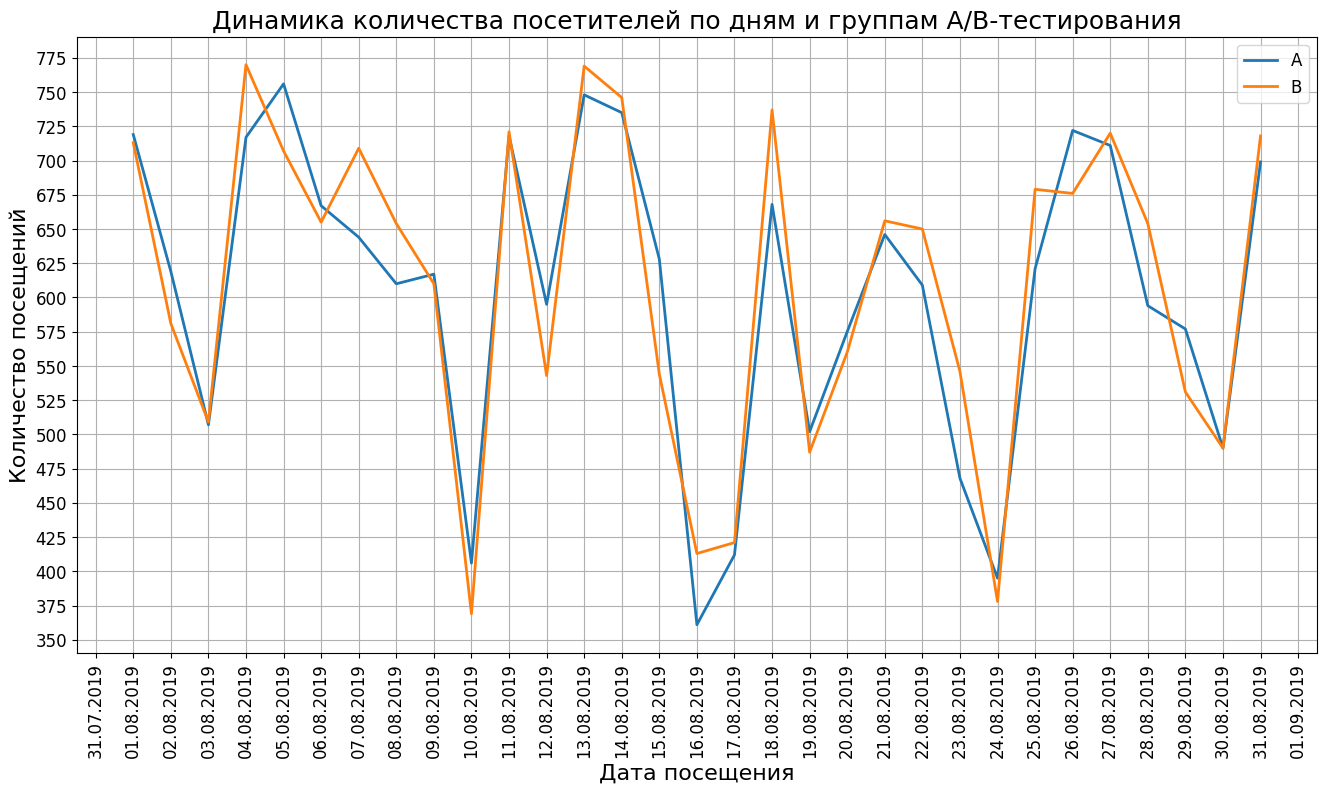

In [28]:
plt.figure(figsize=(16, 8), dpi=100)
plt.plot(visitorsA['date'], visitorsA['visitors'], label='A', linewidth=2)
plt.plot(visitorsB['date'], visitorsB['visitors'], label='B', linewidth=2)
plt.title('Динамика количества посетителей по дням и группам A/B-тестирования', fontsize=18)
plt.xlabel('Дата посещения', fontsize=16)
plt.ylabel('Количество посещений', fontsize=16)
plt.tick_params(axis='y', labelsize=12)
plt.tick_params(axis='x', labelsize=12)
plt.gca().yaxis.set_major_locator(MultipleLocator(25))
plt.gca().xaxis.set_major_locator(MultipleLocator(1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d.%m.%Y'))
plt.xticks(rotation=90)
plt.legend(fontsize=12)  
plt.grid(True)
plt.show()

### Выводы по предобработке данных

В датафреймах hypothesis, orders и visitors нет пропусков и явных дубликатов. В датафрейме orders были найдены 58 пользователей, которые одновременно участвовали и в группе A и в группе B. Мы удалили данных пользователей. Всего из датафрейма orders с учетом того, что один пользователь мог совершить более одного заказа, была удалена 181 строка с такими повторяющимися пользователеями или 15.12%. В динамике количества посетителей по дням и группам A/B-тестирования нет какого-то четкого тренда посещения в разные даты то уменьшались, то увеличивались. При этом мы видим, что у групп A и B данная динамика практически совпадает. Учитывая содержание столбцов в данных таблицах, проверка на неявные дубликаты не имеет смысла. Были приведены к нижнему регистру названия столбцов датафрейма hypothesis и orders. Для последующего анализа были преобразованы из типа строк в формат даты столбцы date в таблицах orders и visitors.

## Приоритизация гипотез

### Добавим новый столбец ICE в датафрейме hypothesis для применения фреймворка ICE для приоритизации гипотез

In [29]:
hypothesis['ICE'] = round((hypothesis['impact'] * hypothesis['confidence']) / hypothesis['efforts'], 2)

### Отсортируем датафрейм hypothesis по столбцу ICE в порядке убывания

In [30]:
hypothesis.sort_values(by = 'ICE', ascending = False)

,hypothesis,reach,impact,confidence,efforts,ICE
8,"Запустить акцию, дающую скидку на товар в день рождения",1,9,9,5,16.20
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",3,10,8,6,13.33
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",10,7,8,5,11.20
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",5,3,8,3,8.00
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",8,3,7,3,7.00
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2,5,4,10,2.00
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",3,2,2,3,1.33
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",8,3,3,8,1.12
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3,1,1,1,1.00


### Добавим новый столбец RICE в датафрейме hypothesis для применения фреймворка RICE для приоритизации гипотез

In [31]:
hypothesis['RICE'] = round((hypothesis['reach'] * hypothesis['impact'] * hypothesis['confidence']) \
                           / hypothesis['efforts'], 2)

### Отсортируем датафрейм hypothesis по столбцу RICE в порядке убывания

In [32]:
hypothesis.sort_values(by = 'RICE', ascending = False)

,hypothesis,reach,impact,confidence,efforts,ICE,RICE
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",10,7,8,5,11.20,112.0
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",8,3,7,3,7.00,56.0
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",3,10,8,6,13.33,40.0
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",5,3,8,3,8.00,40.0
8,"Запустить акцию, дающую скидку на товар в день рождения",1,9,9,5,16.20,16.2
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",8,3,3,8,1.12,9.0
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2,5,4,10,2.00,4.0
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",3,2,2,3,1.33,4.0
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3,1,1,1,1.00,3.0


### Выводы по приоритизации гипотез

1. С точки зрения фреймворка ICE наиболее перспективными являются следующие гипотезы:
- Запустить акцию, дающую скидку на товар в день рождения (9), ICE=16.2.
- Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей (1), ICE=13.33.
- Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок (8), ICE=11.2.
2. С точки зрения фреймворка RICE наиболее перспективными являются следующие гипотезы:
- Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок (8), RICE = 112.
- Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа (3), RICE = 56.
- Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей (1), RICE = 40.
- Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию (7), RICE = 40.
3. Изменение приоритизации гипотез при использовании фреймворка RICE произошло, так как формуле при подсчете RICE присутствет компонент reach — охват пользователей по 10-балльной шкале. У гипотезы под номеров 8 - этот показатель максимальный и это значит данная гипотеза охватывает всех пользователей в интернет магазине. При этом у гипотезы 9 - этот показатель равен 1 и поэтому она находится ниже всех в топ 5 с точки зрения фреймворка RICE.

## Анализ A/B-теста

### Построение графика кумулятивной выручки по группам

#### Создадим массив datesGroups уникальных пар значений дат и групп теста методом drop_duplicates(): 

In [33]:
datesGroups = orders[['date','group']].drop_duplicates()
datesGroups.head(10)

,date,group
0,2019-08-15,B
7,2019-08-15,A
45,2019-08-16,A
47,2019-08-16,B
55,2019-08-01,A
66,2019-08-01,B
86,2019-08-22,A
87,2019-08-22,B
124,2019-08-17,A
125,2019-08-17,B


#### Создадим датфрейм ordersAggregated, где получим агрегированные кумулятивные по дням данные о заказах

In [34]:
ordersAggregated = datesGroups.apply(lambda x: orders[np.logical_and(orders['date'] <= x['date'], orders['group'] == \
                                     x['group'])].agg({'date':'max', 'group':'max', 'transactionid':'nunique', \
                                     'visitorid': 'nunique', 'revenue' : 'sum'}),axis=1).sort_values(by=['date','group'])
ordersAggregated.head(10)

,date,group,transactionid,visitorid,revenue
55,2019-08-01,A,23,19,142779
66,2019-08-01,B,17,17,59758
175,2019-08-02,A,42,36,234381
173,2019-08-02,B,40,39,221801
291,2019-08-03,A,66,60,346854
383,2019-08-03,B,54,53,288850
499,2019-08-04,A,77,71,388030
498,2019-08-04,B,68,66,385740
719,2019-08-05,A,99,92,474413
699,2019-08-05,B,89,87,475648


#### Создадим датафреймей visitorsAggregated, где получим агрегированные кумулятивные по дням данные о посетителях интернет-магазина

In [35]:
visitorsAggregated = datesGroups.apply(lambda x: visitors[np.logical_and(visitors['date'] <= x['date'], visitors['group']\
                                       == x['group'])].agg({'date':'max', 'group':'max', 'visitors':'sum'}), axis=1)\
                                       .sort_values(by=['date','group'])
visitorsAggregated.head(10)

,date,group,visitors
55,2019-08-01,A,719
66,2019-08-01,B,713
175,2019-08-02,A,1338
173,2019-08-02,B,1294
291,2019-08-03,A,1845
383,2019-08-03,B,1803
499,2019-08-04,A,2562
498,2019-08-04,B,2573
719,2019-08-05,A,3318
699,2019-08-05,B,3280


#### Объединяем кумулятивные данные в одной таблице cumulativeData и присваиваем ее столбцам понятные названия

In [36]:
cumulativeData = ordersAggregated.merge(visitorsAggregated, left_on=['date', 'group'], right_on=['date', 'group'])
cumulativeData.columns = ['date', 'group', 'orders', 'buyers', 'revenue', 'visitors']
cumulativeData.head(10)

,date,group,orders,buyers,revenue,visitors
0,2019-08-01,A,23,19,142779,719
1,2019-08-01,B,17,17,59758,713
2,2019-08-02,A,42,36,234381,1338
3,2019-08-02,B,40,39,221801,1294
4,2019-08-03,A,66,60,346854,1845
5,2019-08-03,B,54,53,288850,1803
6,2019-08-04,A,77,71,388030,2562
7,2019-08-04,B,68,66,385740,2573
8,2019-08-05,A,99,92,474413,3318
9,2019-08-05,B,89,87,475648,3280


#### Создадим датафрейм cumulativeRevenueA с кумулятивным количеством заказов и кумулятивной выручкой по дням в группе А

In [37]:
cumulativeRevenueA = cumulativeData[cumulativeData['group']=='A'][['date','revenue', 'orders']]
cumulativeRevenueA.head(10)

,date,revenue,orders
0,2019-08-01,142779,23
2,2019-08-02,234381,42
4,2019-08-03,346854,66
6,2019-08-04,388030,77
8,2019-08-05,474413,99
10,2019-08-06,515332,114
12,2019-08-07,638580,130
14,2019-08-08,727219,144
16,2019-08-09,861456,155
18,2019-08-10,1013731,170


#### Создадим датафрейм cumulativeRevenueB с кумулятивным количеством заказов и кумулятивной выручкой по дням в группе B

In [38]:
cumulativeRevenueB = cumulativeData[cumulativeData['group']=='B'][['date','revenue', 'orders']]
cumulativeRevenueB.head(10)

,date,revenue,orders
1,2019-08-01,59758,17
3,2019-08-02,221801,40
5,2019-08-03,288850,54
7,2019-08-04,385740,68
9,2019-08-05,475648,89
11,2019-08-06,690490,112
13,2019-08-07,909654,135
15,2019-08-08,1059795,157
17,2019-08-09,1162961,176
19,2019-08-10,1268123,198


#### Построим графики кумулятивной выручки по дням и группам A/B-тестирования

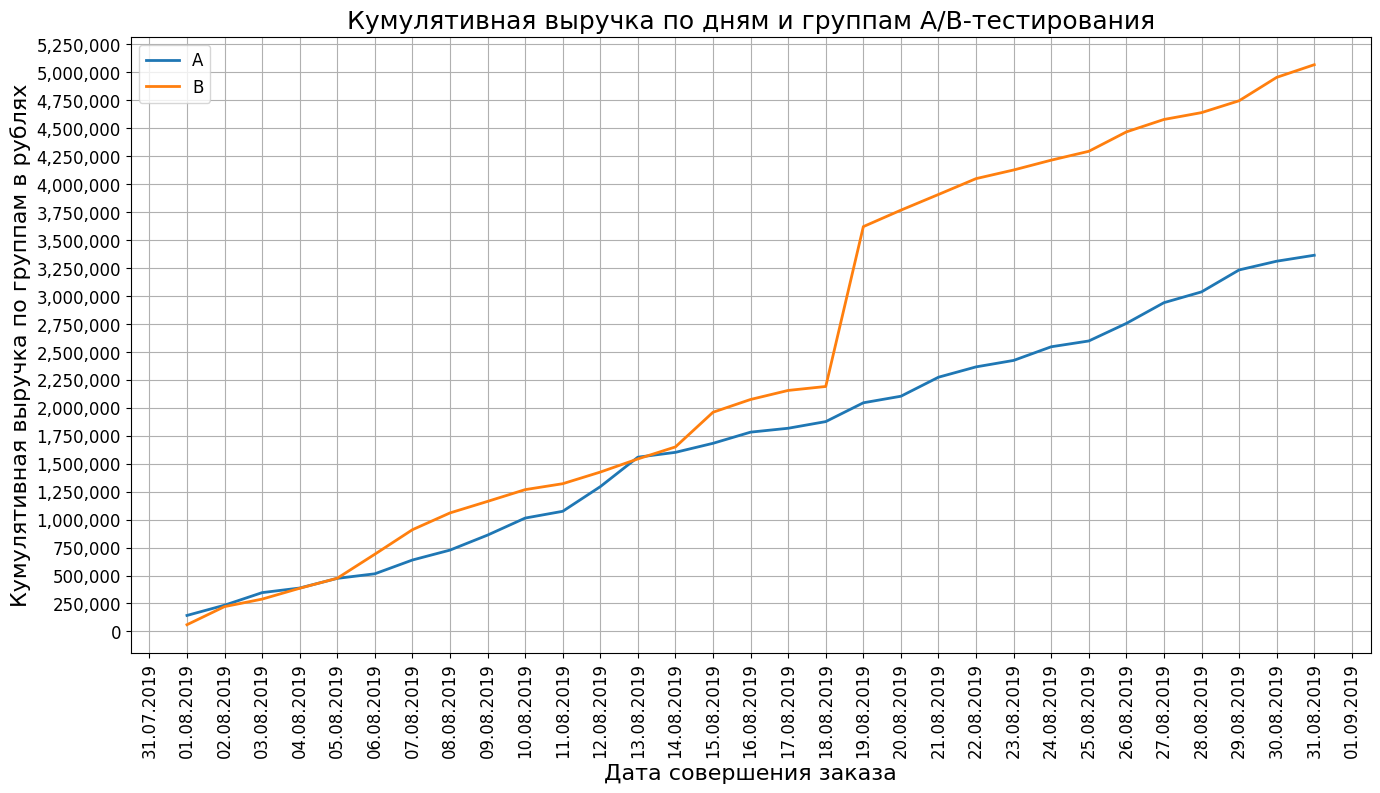

In [39]:
plt.figure(figsize=(16, 8), dpi=100)
plt.ticklabel_format(style='plain')
formatter = ticker.FuncFormatter(lambda x, _: '{:,.0f}'.format(x))
plt.gca().yaxis.set_major_formatter(formatter)
plt.plot(cumulativeRevenueA['date'], cumulativeRevenueA['revenue'], label='A', linewidth=2)
plt.plot(cumulativeRevenueB['date'], cumulativeRevenueB['revenue'], label='B', linewidth=2)
plt.xlabel('Дата совершения заказа', fontsize=16)
plt.ylabel('Кумулятивная выручка по группам в рублях', fontsize=16)
plt.title('Кумулятивная выручка по дням и группам A/B-тестирования', fontsize=18)
plt.tick_params(axis='y', labelsize=12)
plt.tick_params(axis='x', labelsize=12)
plt.gca().yaxis.set_major_locator(MultipleLocator(250000))
plt.gca().xaxis.set_major_locator(MultipleLocator(1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d.%m.%Y'))
plt.xticks(rotation=90)
plt.legend(fontsize=12)  
plt.grid(True)
plt.show()

**Выводы**: Практически с начала теста кумулятивная выручка в группе B опережала группу A и росла примерно одинаково до 18.08.2019. На 19.08.2019 наблюдаем резкий рост кумулятивной выручки группы B примерно с 2 250 000 рублей 18.08.2019 до примерно 3 600 000 рублей. Этот скачок может свидетесльтвовать либо о всплеске количества заказов, то есть увеличения конверсии, либо о появлении очень дорогих заказов. Далее наблюдаем продолжающийся планый рост до примерно 5 000 000 рублей параллельно с группой A.

### Построим графики среднего чека по группам, разделив кумулятивную выручку на кумулятивное число заказов

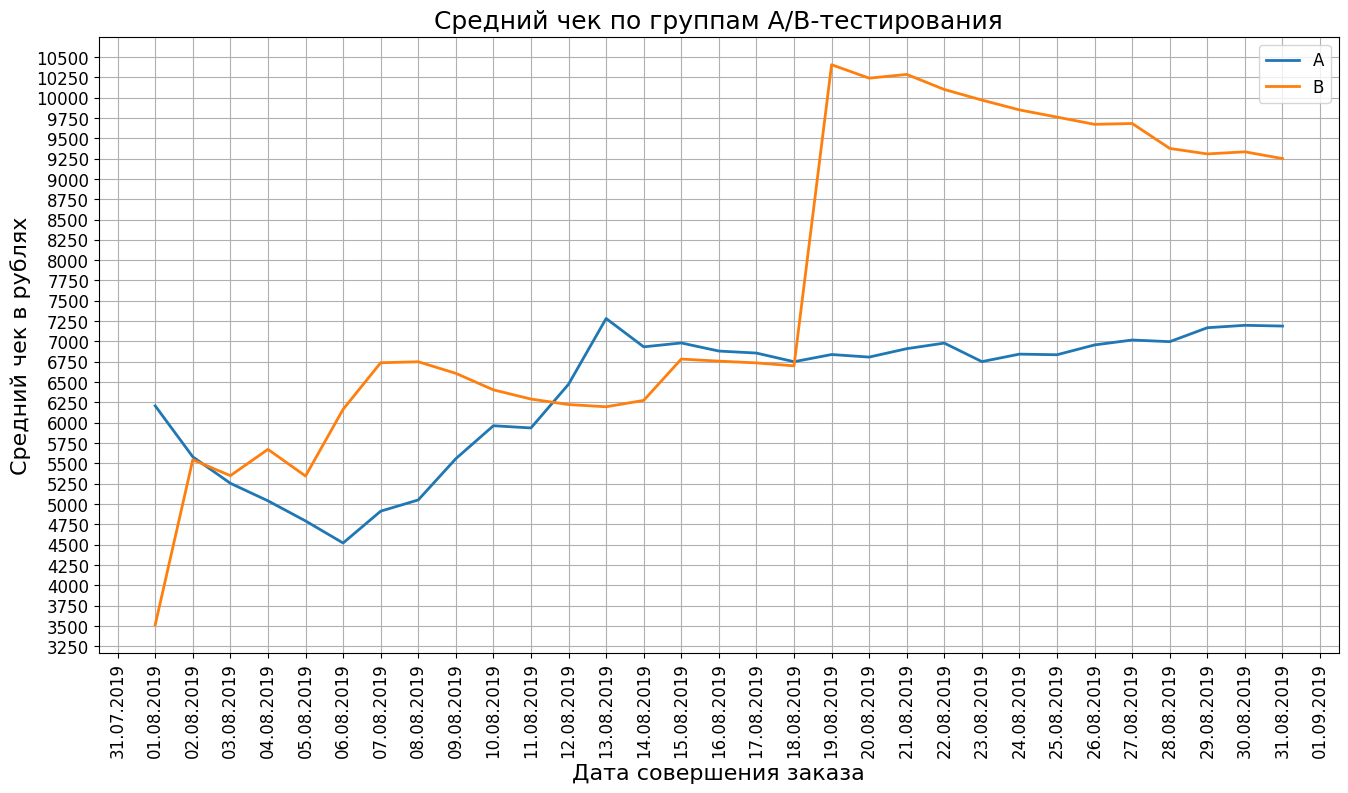

In [40]:
plt.figure(figsize=(16, 8), dpi=100)
plt.plot(cumulativeRevenueA['date'], cumulativeRevenueA['revenue']/cumulativeRevenueA['orders'], label='A', linewidth=2)
plt.plot(cumulativeRevenueB['date'], cumulativeRevenueB['revenue']/cumulativeRevenueB['orders'], label='B', linewidth=2)
plt.xlabel('Дата совершения заказа', fontsize=16)
plt.ylabel('Средний чек в рублях', fontsize=16)
plt.title('Средний чек по группам A/B-тестирования', fontsize=18)
plt.tick_params(axis='y', labelsize=12)
plt.tick_params(axis='x', labelsize=12)
plt.gca().yaxis.set_major_locator(MultipleLocator(250))
plt.gca().xaxis.set_major_locator(MultipleLocator(1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d.%m.%Y'))
plt.xticks(rotation=90)
plt.legend(fontsize=12)  
plt.grid(True)
plt.show()

**Выводы**: Средний чек группы B резкой вырос 19.08.2019 с 6750 рублей до 10500 рублей. Далее наблюдаем плавное снижение чека в группе до 9250  рублей до конца теста. При этом средний чек группы A изначально был выше группы B в начале теста в 6250 рублей, затем резкое снижение до 4500 рублей до 06.08.2019, далее резки рост до 7250 рублей до 13.08.2019 и далее оставался примерно на таком уровне до конца теста.

### Построение графика относительного различия для среднего чека

#### Cобираем данные в одном датафрейме mergedCumulativeRevenue

In [41]:
mergedCumulativeRevenue = cumulativeRevenueA.merge(cumulativeRevenueB, left_on='date', right_on=\
                                                   'date', how='left', suffixes=['A', 'B'])
mergedCumulativeRevenue.head(10)

,date,revenueA,ordersA,revenueB,ordersB
0,2019-08-01,142779,23,59758,17
1,2019-08-02,234381,42,221801,40
2,2019-08-03,346854,66,288850,54
3,2019-08-04,388030,77,385740,68
4,2019-08-05,474413,99,475648,89
5,2019-08-06,515332,114,690490,112
6,2019-08-07,638580,130,909654,135
7,2019-08-08,727219,144,1059795,157
8,2019-08-09,861456,155,1162961,176
9,2019-08-10,1013731,170,1268123,198


#### Построим график относительного различия для среднего чека между группами A/B-тестирования

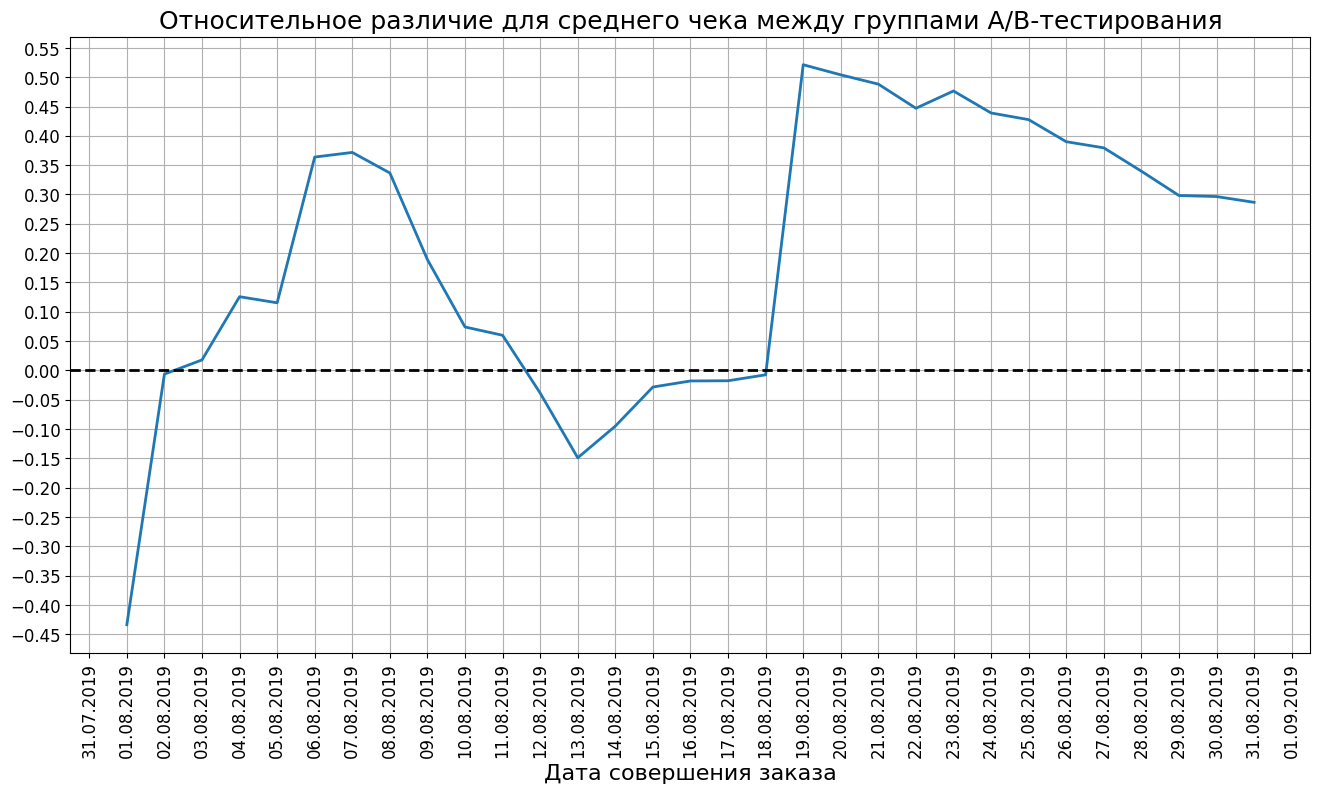

In [42]:
plt.figure(figsize=(16, 8), dpi=100)
plt.plot(mergedCumulativeRevenue['date'], (mergedCumulativeRevenue['revenueB']/mergedCumulativeRevenue['ordersB'])/\
         (mergedCumulativeRevenue['revenueA']/mergedCumulativeRevenue['ordersA'])-1, linewidth=2)
plt.xlabel('Дата совершения заказа', fontsize=16)
plt.title('Относительное различие для среднего чека между группами A/B-тестирования', fontsize=18)
plt.tick_params(axis='y', labelsize=12)
plt.tick_params(axis='x', labelsize=12)
plt.gca().yaxis.set_major_locator(MultipleLocator(0.05))
plt.gca().xaxis.set_major_locator(MultipleLocator(1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d.%m.%Y'))
plt.xticks(rotation=90)
plt.axhline(y=0, color='black', linestyle='--', linewidth=2)
plt.grid(True)
plt.show()

**Выводы**: В точках 01.08.2019, 07.08.2019, 13.08.2019, 19.08.2019, 31.08.2019 график относительного различия резко изменялся. Это может быть свзано с аномально крупными зазказами, которые нам стоит определить.

### Построение графика кумулятивного среднего количества заказов на посетителя по группам

#### Посчитаем среднее количество заказов на посетителя

In [43]:
cumulativeData['conversion'] = cumulativeData['orders']/cumulativeData['visitors']
cumulativeData.head(10)

,date,group,orders,buyers,revenue,visitors,conversion
0,2019-08-01,A,23,19,142779,719,0.031989
1,2019-08-01,B,17,17,59758,713,0.023843
2,2019-08-02,A,42,36,234381,1338,0.031390
3,2019-08-02,B,40,39,221801,1294,0.030912
4,2019-08-03,A,66,60,346854,1845,0.035772
5,2019-08-03,B,54,53,288850,1803,0.029950
6,2019-08-04,A,77,71,388030,2562,0.030055
7,2019-08-04,B,68,66,385740,2573,0.026428
8,2019-08-05,A,99,92,474413,3318,0.029837
9,2019-08-05,B,89,87,475648,3280,0.027134


#### Создадим датафрейм cumulativeDataA, где будут только данные по группе A

In [44]:
cumulativeDataA = cumulativeData[cumulativeData['group']=='A']
cumulativeDataA.head(10)

,date,group,orders,buyers,revenue,visitors,conversion
0,2019-08-01,A,23,19,142779,719,0.031989
2,2019-08-02,A,42,36,234381,1338,0.031390
4,2019-08-03,A,66,60,346854,1845,0.035772
6,2019-08-04,A,77,71,388030,2562,0.030055
8,2019-08-05,A,99,92,474413,3318,0.029837
10,2019-08-06,A,114,104,515332,3985,0.028607
12,2019-08-07,A,130,120,638580,4629,0.028084
14,2019-08-08,A,144,133,727219,5239,0.027486
16,2019-08-09,A,155,143,861456,5856,0.026469
18,2019-08-10,A,170,158,1013731,6262,0.027148


#### Создадим датафрейм cumulativeDataB, где будут только данные по группе B

In [45]:
cumulativeDataB = cumulativeData[cumulativeData['group']=='B']
cumulativeDataB.head(10)

,date,group,orders,buyers,revenue,visitors,conversion
1,2019-08-01,B,17,17,59758,713,0.023843
3,2019-08-02,B,40,39,221801,1294,0.030912
5,2019-08-03,B,54,53,288850,1803,0.029950
7,2019-08-04,B,68,66,385740,2573,0.026428
9,2019-08-05,B,89,87,475648,3280,0.027134
11,2019-08-06,B,112,109,690490,3935,0.028463
13,2019-08-07,B,135,132,909654,4644,0.029070
15,2019-08-08,B,157,154,1059795,5298,0.029634
17,2019-08-09,B,176,173,1162961,5908,0.029790
19,2019-08-10,B,198,195,1268123,6277,0.031544


#### Построим график кумулятивного среднего количества заказов на посетителя по группам

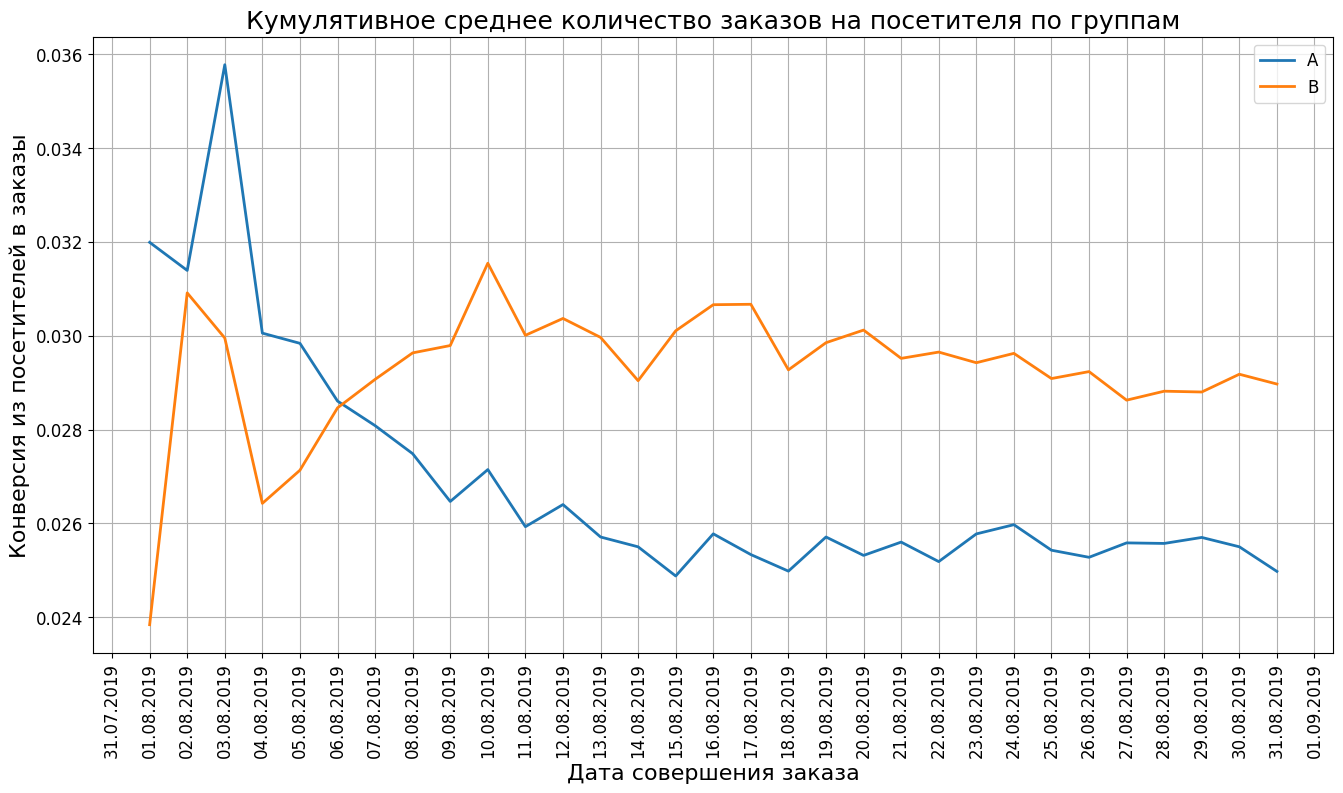

In [46]:
plt.figure(figsize=(16, 8), dpi=100)
plt.plot(cumulativeDataA['date'], cumulativeDataA['conversion'], label='A', linewidth=2)
plt.plot(cumulativeDataB['date'], cumulativeDataB['conversion'], label='B', linewidth=2)
plt.xlabel('Дата совершения заказа', fontsize=16)
plt.ylabel('Конверсия из посетителей в заказы', fontsize=16)
plt.title('Кумулятивное среднее количество заказов на посетителя по группам', fontsize=18)
plt.tick_params(axis='y', labelsize=12)
plt.tick_params(axis='x', labelsize=12)
plt.gca().xaxis.set_major_locator(MultipleLocator(1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d.%m.%Y'))
plt.xticks(rotation=90)
plt.legend(fontsize=12) 
plt.grid(True)
plt.show()

**Выводы**: Наичная с 06.08.2019 и до конца теста среднее количество заказов на посетителя по группе B было стабильно выше группы A.

### Построение график относительного изменения кумулятивного среднего количества заказов на посетителя группы B к группе A

#### Объединим результаты конверсии из посетителей в заказы в одну таблицу для обеих групп

In [47]:
mergedCumulativeConversions = cumulativeDataA[['date','conversion']].merge(cumulativeDataB[['date','conversion']], \
                                             left_on='date', right_on='date', how='left', suffixes=['A', 'B'])
mergedCumulativeConversions.head(10)

,date,conversionA,conversionB
0,2019-08-01,0.031989,0.023843
1,2019-08-02,0.031390,0.030912
2,2019-08-03,0.035772,0.029950
3,2019-08-04,0.030055,0.026428
4,2019-08-05,0.029837,0.027134
5,2019-08-06,0.028607,0.028463
6,2019-08-07,0.028084,0.029070
7,2019-08-08,0.027486,0.029634
8,2019-08-09,0.026469,0.029790
9,2019-08-10,0.027148,0.031544


#### Построим график относительного изменения кумулятивного среднего количества заказов на посетителя группы B к группе A

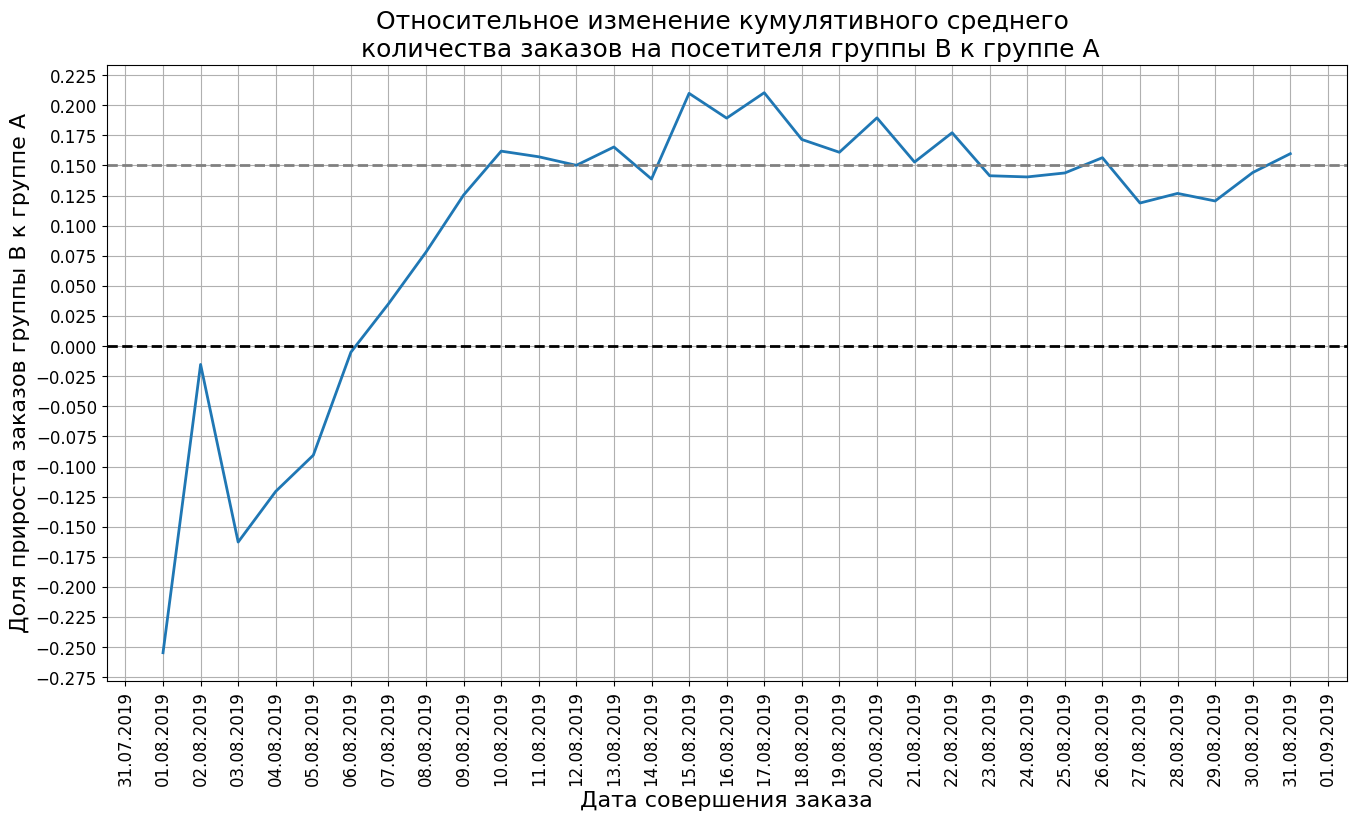

In [48]:
plt.figure(figsize=(16, 8), dpi=100)
plt.plot(mergedCumulativeConversions['date'], mergedCumulativeConversions['conversionB']/\
         mergedCumulativeConversions['conversionA']-1, linewidth=2)
plt.xlabel('Дата совершения заказа', fontsize=16)
plt.ylabel('Доля прироста заказов группы B к группе A', fontsize=16)
plt.title('Относительное изменение кумулятивного среднего \n количества заказов на посетителя группы B к группе A', \
          fontsize=18)
plt.axhline(y=0, color='black', linestyle='--', linewidth=2)
plt.axhline(y=0.15, color='grey', linestyle='--', linewidth=2)
plt.tick_params(axis='y', labelsize=12)
plt.tick_params(axis='x', labelsize=12)
plt.gca().yaxis.set_major_locator(MultipleLocator(0.025))
plt.gca().xaxis.set_major_locator(MultipleLocator(1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d.%m.%Y'))
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

**Выводы**: Начиная с 06.08.2019 группа B лидирует по метрике среднего количества заказов на посетителя и зафиксировалась около прироста примерно в 15% относительно группы A.

### Построение точечного графика количества заказов по пользователям

#### Создадим датафрейм ordersByUsers где будут собраны уникальные пользователи и количество их заказов

In [49]:
ordersByUsers = (orders.groupby('visitorid', as_index=False).agg({'transactionid' : 'nunique'}))
ordersByUsers.columns = ['orderid', 'orders']
ordersByUsers.sort_values(by='orders', ascending=False).head(10)

,orderid,orders
908,3967698036,3
55,249864742,3
478,2108163459,3
687,2988190573,3
890,3908431265,3
138,611059232,3
632,2742574263,3
157,678354126,2
323,1404560065,2
452,1985475298,2


#### Создадим серию из чисел от 0 до количества наблюдений в датфрейме ordersByUsers

In [50]:
x_values = pd.Series(range(0, len(ordersByUsers)))
x_values.head(10)

0    0
1    1
2    2
3    3
4    4
5    5
6    6
7    7
8    8
9    9
dtype: int64

#### Построим точечный графика количества заказов по пользователям

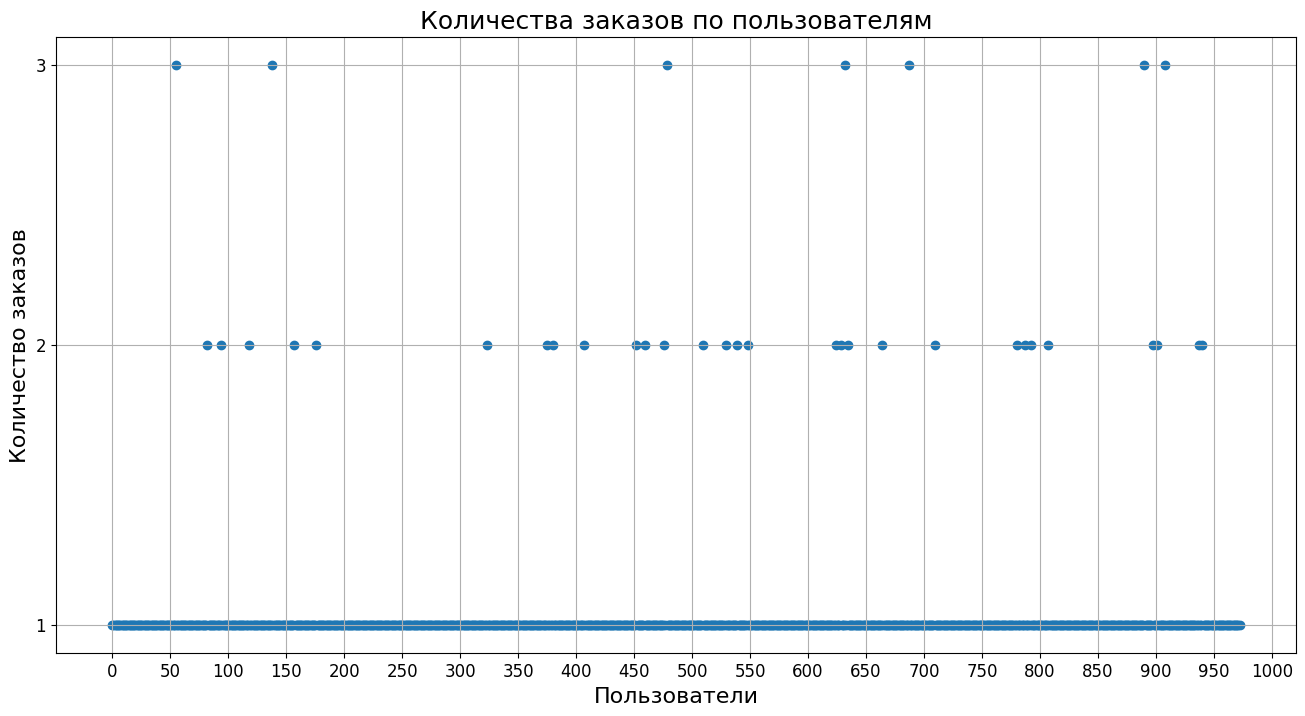

In [51]:
plt.figure(figsize=(16, 8), dpi=100)
plt.scatter(x_values, ordersByUsers['orders'])
plt.xlabel('Пользователи', fontsize=16)
plt.ylabel('Количество заказов', fontsize=16)
plt.title('Количества заказов по пользователям', fontsize=18)
plt.gca().yaxis.set_major_locator(MultipleLocator(1))
plt.gca().xaxis.set_major_locator(MultipleLocator(50))
plt.tick_params(axis='y', labelsize=12)
plt.tick_params(axis='x', labelsize=12)
plt.grid(True)
plt.show()

**Выводы**: Большая часть пользователей делала не более 1 - 2 заказов. Также есть по 3 заказа, однако понять какое количество заказов можно отнести к выбросам можно с помощью выборочных перецентилей.

### Подсчет выборочных перцентилей количества заказов на пользователя

#### Подсчитаем 95-й и 99-й перцентили количества заказов на пользователя

In [52]:
print(np.percentile(ordersByUsers['orders'], [95, 99]))

[1. 2.]


**Выводы**: Не более 5 % пользователей совершали 1 и более зазказа и не более 1 % пользователей совершили 2 заказа и более. Примем за верхнюю границу для определения аномальных пользователей 2 заказа.

### Построение точечного графика стоимостей заказов

#### Создадим серию из чисел от 0 до количества наблюдений в датфрейме orders

In [53]:
x_values = pd.Series(range(0, len(orders['revenue'])))
x_values.head(10)

0    0
1    1
2    2
3    3
4    4
5    5
6    6
7    7
8    8
9    9
dtype: int64

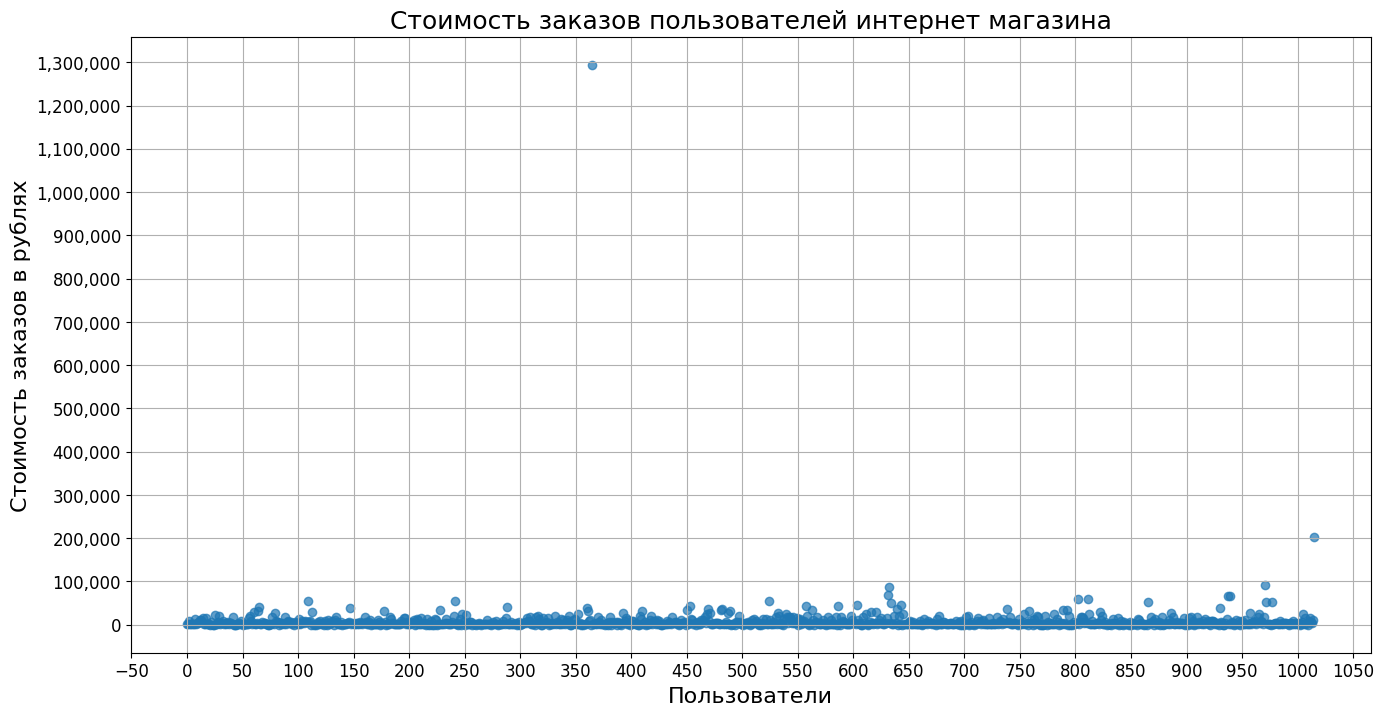

In [54]:
plt.figure(figsize=(16, 8), dpi=100)
formatter = ticker.FuncFormatter(lambda x, _: '{:,.0f}'.format(x))
plt.gca().yaxis.set_major_formatter(formatter)
plt.scatter(x_values, orders['revenue'], alpha = 0.7)
plt.xlabel('Пользователи', fontsize=16)
plt.ylabel('Стоимость заказов в рублях', fontsize=16)
plt.title('Стоимость заказов пользователей интернет магазина', fontsize=18)
plt.tick_params(axis='y', labelsize=12)
plt.tick_params(axis='x', labelsize=12)
plt.gca().yaxis.set_major_locator(MultipleLocator(100000))
plt.gca().xaxis.set_major_locator(MultipleLocator(50))
plt.grid()
plt.show()

**Выводы**: На графике видно аномальный зазаз в 1 300 000 рублей и 200 000 рублей, однако понять выше какой суммы заказов можно отнести к выбросам можно с помощью выборочных перецентилей.

### Подсчет выборочных перцентилей суммы заказов пользователей

#### Подсчитаем 95-й и 99-й перцентили суммы заказов пользователей

In [55]:
print(np.percentile(orders['revenue'], [95, 99]))

[26785. 53904.]


**Выводы**: Не более 5 % пользователей совершали заказ на сумму более 26 785 рублей и и не болеее 1 % пользователей совершили заказ на сумму более 53 904 рублей. Примем за верхнюю границу для определения аномальной стоимости заказов 53 904 рубля.

### Подсчет статистической значимости различий в среднем количестве заказов на посетителя между группами по «сырым» данным

#### Сформулируем гипотезы

H0:Среднее количество заказов на посетителя групп A и B равны, статистически значимых отличий нет.

H1:Среднем количество заказов на посетителя групп A и B различны, статистически значимые отличия есть.

#### Создадим датафрейм visitorsADaily где будут собраны даты посещения и количество пользователей в указанную дату для группы A

In [56]:
visitorsADaily = visitors[visitors['group'] == 'A'][['date', 'visitors']]
visitorsADaily.columns = ['date', 'visitorsPerDateA']
visitorsADaily.head(10)

,date,visitorsPerDateA
0,2019-08-01,719
1,2019-08-02,619
2,2019-08-03,507
3,2019-08-04,717
4,2019-08-05,756
5,2019-08-06,667
6,2019-08-07,644
7,2019-08-08,610
8,2019-08-09,617
9,2019-08-10,406


#### Создадим датафрейм visitorsACummulative где будут собраны даты посещения и кумулятивное количество пользователей на указанную дату для группы A

In [57]:
visitorsACummulative = visitorsADaily.apply(
    lambda x: visitorsADaily[visitorsADaily['date'] <= x['date']].agg(
        {'date': 'max', 'visitorsPerDateA': 'sum'}
    ),
    axis=1,
)
visitorsACummulative.columns = ['date', 'visitorsCummulativeA']

visitorsACummulative.head(10)

,date,visitorsCummulativeA
0,2019-08-01,719
1,2019-08-02,1338
2,2019-08-03,1845
3,2019-08-04,2562
4,2019-08-05,3318
5,2019-08-06,3985
6,2019-08-07,4629
7,2019-08-08,5239
8,2019-08-09,5856
9,2019-08-10,6262


#### Создадим датафрейм visitorsBDaily, где будут собраны даты посещения и количество пользователей в указанную дату для группы B

In [58]:
visitorsBDaily = visitors[visitors['group'] == 'B'][['date', 'visitors']]
visitorsBDaily.columns = ['date', 'visitorsPerDateB']
visitorsBDaily.head(10)

,date,visitorsPerDateB
31,2019-08-01,713
32,2019-08-02,581
33,2019-08-03,509
34,2019-08-04,770
35,2019-08-05,707
36,2019-08-06,655
37,2019-08-07,709
38,2019-08-08,654
39,2019-08-09,610
40,2019-08-10,369


#### Создадим датафрейм visitorsBCummulative где будут собраны даты посещения и кумулятивное количество пользователей на указанную дату для группы B

In [59]:
visitorsBCummulative = visitorsBDaily.apply(
    lambda x: visitorsBDaily[visitorsBDaily['date'] <= x['date']].agg(
        {'date': 'max', 'visitorsPerDateB': 'sum'}
    ),
    axis=1,
)
visitorsBCummulative.columns = ['date', 'visitorsCummulativeB']

visitorsBCummulative.head(10)

,date,visitorsCummulativeB
31,2019-08-01,713
32,2019-08-02,1294
33,2019-08-03,1803
34,2019-08-04,2573
35,2019-08-05,3280
36,2019-08-06,3935
37,2019-08-07,4644
38,2019-08-08,5298
39,2019-08-09,5908
40,2019-08-10,6277


#### Создадим датафрейм ordersADaily где будут собраны дата заказа, количество заказов на эту дату и сумма выручки на эту дату для группы A

In [60]:
ordersADaily = (
    orders[orders['group'] == 'A'][['date', 'transactionid', 'visitorid', 'revenue']]
    .groupby('date', as_index=False)
    .agg({'transactionid': pd.Series.nunique, 'revenue': 'sum'})
)
ordersADaily.columns = ['date', 'ordersPerDateA', 'revenuePerDateA']
ordersADaily.head(10)

,date,ordersPerDateA,revenuePerDateA
0,2019-08-01,23,142779
1,2019-08-02,19,91602
2,2019-08-03,24,112473
3,2019-08-04,11,41176
4,2019-08-05,22,86383
5,2019-08-06,15,40919
6,2019-08-07,16,123248
7,2019-08-08,14,88639
8,2019-08-09,11,134237
9,2019-08-10,15,152275


#### Создадим датафрейм ordersACummulative где будут собраны дата заказа, кумулятивное количество заказов на эту дату и кумулятивная сумма выручки на эту дату для группы A

In [61]:
ordersACummulative = ordersADaily.apply(
    lambda x: ordersADaily[ordersADaily['date'] <= x['date']].agg(
        {'date': 'max', 'ordersPerDateA': 'sum', 'revenuePerDateA': 'sum'}
    ),
    axis=1,
).sort_values(by=['date'])
ordersACummulative.columns = [
    'date',
    'ordersCummulativeA',
    'revenueCummulativeA',
]

ordersACummulative.head(10)

,date,ordersCummulativeA,revenueCummulativeA
0,2019-08-01,23,142779
1,2019-08-02,42,234381
2,2019-08-03,66,346854
3,2019-08-04,77,388030
4,2019-08-05,99,474413
5,2019-08-06,114,515332
6,2019-08-07,130,638580
7,2019-08-08,144,727219
8,2019-08-09,155,861456
9,2019-08-10,170,1013731


#### Создадим датафрейм ordersBDaily где будут собраны дата заказа, количество заказов на эту дату и сумма выручки на эту дату для группы B

In [62]:
ordersBDaily = (
    orders[orders['group'] == 'B'][['date', 'transactionid', 'visitorid', 'revenue']]
    .groupby('date', as_index=False)
    .agg({'transactionid': pd.Series.nunique, 'revenue': 'sum'})
)
ordersBDaily.columns = ['date', 'ordersPerDateB', 'revenuePerDateB']
ordersBDaily.head(10)

,date,ordersPerDateB,revenuePerDateB
0,2019-08-01,17,59758
1,2019-08-02,23,162043
2,2019-08-03,14,67049
3,2019-08-04,14,96890
4,2019-08-05,21,89908
5,2019-08-06,23,214842
6,2019-08-07,23,219164
7,2019-08-08,22,150141
8,2019-08-09,19,103166
9,2019-08-10,22,105162


#### Создадим датафрейм ordersBCummulative где будут собраны дата заказа, кумулятивное количество заказов на эту дату и кумулятивная сумма выручки на эту дату для группы B

In [63]:
ordersBCummulative = ordersBDaily.apply(
    lambda x: ordersBDaily[ordersBDaily['date'] <= x['date']].agg(
        {'date': 'max', 'ordersPerDateB': 'sum', 'revenuePerDateB': 'sum'}
    ),
    axis=1,
).sort_values(by=['date'])
ordersBCummulative.columns = [
    'date',
    'ordersCummulativeB',
    'revenueCummulativeB',
]

ordersBCummulative.head(10)

,date,ordersCummulativeB,revenueCummulativeB
0,2019-08-01,17,59758
1,2019-08-02,40,221801
2,2019-08-03,54,288850
3,2019-08-04,68,385740
4,2019-08-05,89,475648
5,2019-08-06,112,690490
6,2019-08-07,135,909654
7,2019-08-08,157,1059795
8,2019-08-09,176,1162961
9,2019-08-10,198,1268123


#### Объединим датафреймы ordersADaily, ordersACummulative, ordersBCummulative, visitorsADaily, visitorsBDaily, visitorsACummulative, visitorsBCummulative в один датафрейм data со следующими столбцами:

    date — дата;
    ordersPerDateA — количество заказов в выбранную дату в группе A;
    revenuePerDateA — суммарная выручка в выбранную дату в группе A;
    ordersPerDateB — количество заказов в выбранную дату в группе B;
    revenuePerDateB — суммарная выручка в выбранную дату в группе B;
    ordersCummulativeA — суммарное число заказов до выбранной даты включительно в группе A;
    revenueCummulativeA — суммарная выручка до выбранной даты включительно в группе A;
    ordersCummulativeB — суммарное количество заказов до выбранной даты включительно в группе B;
    revenueCummulativeB — суммарная выручка до выбранной даты включительно в группе B;
    visitorsPerDateA — количество пользователей в выбранную дату в группе A;
    visitorsPerDateB — количество пользователей в выбранную дату в группе B;
    visitorsCummulativeA  — количество пользователей до выбранной даты включительно в группе A;
    visitorsCummulativeB — количество пользователей до выбранной даты включительно в группе B.

In [64]:
data = (
    ordersADaily.merge(
        ordersBDaily, left_on='date', right_on='date', how='left'
    )
    .merge(ordersACummulative, left_on='date', right_on='date', how='left')
    .merge(ordersBCummulative, left_on='date', right_on='date', how='left')
    .merge(visitorsADaily, left_on='date', right_on='date', how='left')
    .merge(visitorsBDaily, left_on='date', right_on='date', how='left')
    .merge(visitorsACummulative, left_on='date', right_on='date', how='left')
    .merge(visitorsBCummulative, left_on='date', right_on='date', how='left')
)

data.head(10).T

,0,1,2,3,4,5,6,7,8,9
date,2019-08-01 00:00:00,2019-08-02 00:00:00,2019-08-03 00:00:00,2019-08-04 00:00:00,2019-08-05 00:00:00,2019-08-06 00:00:00,2019-08-07 00:00:00,2019-08-08 00:00:00,2019-08-09 00:00:00,2019-08-10 00:00:00
ordersPerDateA,23,19,24,11,22,15,16,14,11,15
revenuePerDateA,142779,91602,112473,41176,86383,40919,123248,88639,134237,152275
ordersPerDateB,17,23,14,14,21,23,23,22,19,22
revenuePerDateB,59758,162043,67049,96890,89908,214842,219164,150141,103166,105162
ordersCummulativeA,23,42,66,77,99,114,130,144,155,170
revenueCummulativeA,142779,234381,346854,388030,474413,515332,638580,727219,861456,1013731
ordersCummulativeB,17,40,54,68,89,112,135,157,176,198
revenueCummulativeB,59758,221801,288850,385740,475648,690490,909654,1059795,1162961,1268123
visitorsPerDateA,719,619,507,717,756,667,644,610,617,406


#### Создадим переменные ordersByUsersA и ordersByUsersB со столбцами userid и orders. В них для пользователей, которые заказывали хотя бы 1 раз, укажем число совершённых заказов

In [65]:
ordersByUsersA = (orders[orders['group'] == 'A'].groupby('visitorid', as_index=\
                                                         False).agg({'transactionid': pd.Series.nunique}))
ordersByUsersA.columns = ['userid', 'orders']

ordersByUsersB = (orders[orders['group'] == 'B'].groupby('visitorid', as_index=\
                                                         False).agg({'transactionid': pd.Series.nunique}))
ordersByUsersB.columns = ['userid', 'orders']

print(ordersByUsersA.sort_values(by = 'orders', ascending = False).head(10))
print()
print(ordersByUsersB.sort_values(by = 'orders', ascending = False).head(10))

         userid  orders
58    611059232       3
211  2108163459       3
310  2988190573       3
409  3908431265       3
416  3967698036       3
302  2892265953       2
374  3469608676       2
72    759473111       2
286  2744017357       2
282  2733145037       2

         userid  orders
347  2742574263       3
33    249864742       3
486  3935952912       2
256  2025197455       2
418  3332057097       2
51    406208401       2
507  4134830387       2
250  1985475298       2
296  2366521417       2
421  3362039251       2


#### Объявим переменные sampleA и sampleB, в которых пользователям из разных групп будет соответствовать количество заказов. Тем, кто ничего не заказал, будут соответствовать нули. Это нужно, чтобы подготовить выборки к проверке критерием Манна-Уитни

In [66]:
sampleA = pd.concat([ordersByUsersA['orders'],pd.Series(0, index=np.arange(data['visitorsPerDateA'].sum() - \
                                                        len(ordersByUsersA['orders'])), name='orders')],axis=0)

sampleB = pd.concat([ordersByUsersB['orders'],pd.Series(0, index=np.arange(data['visitorsPerDateB'].sum() - \
                                                        len(ordersByUsersB['orders'])), name='orders')],axis=0)
print(sampleA.head(10))
print()
print(sampleB.head(10))

0    1
1    1
2    1
3    1
4    1
5    1
6    1
7    1
8    1
9    1
Name: orders, dtype: int64

0    1
1    1
2    1
3    1
4    1
5    1
6    1
7    1
8    1
9    1
Name: orders, dtype: int64


#### Применим критерий Манна-Уитни для переменных sampleA и sampleB для проверки гипотезы различий в среднем количестве заказов на посетителя между группами по «сырым» данным

In [67]:
alpha = 0.05

p_value = stats.mannwhitneyu(sampleA, sampleB)[1]

print("P-value: {0:.3f}".format(p_value))

if (p_value < alpha):
    print("Отвергаем нулевую гипотезу: между группами есть разница")
else:
    print("Не получилось отвергнуть нулевую гипотезу, нет оснований считать группы разными")
    
print('Относительные различия:',"{0:.3f}".format(sampleB.mean() / sampleA.mean() - 1))

P-value: 0.011
Отвергаем нулевую гипотезу: между группами есть разница
Относительные различия: 0.160


**Вывод:** P-value значительно меньше 0.05, значит стоит отвергнуть нулевую гипотезу. "Сырые данные" говорят о том, что в среднем количестве заказов между группами есть статистически значимые различия. Относительный прирост среднего группы В к конверсии группы А равен 16%.

### Подсчет статистической значимости различий в среднем чеке заказа между группами по «сырым» данным

#### Сформулируем гипотезы

H0:Средние чеки групп A и B равны, статистически значимых отличий нет.

H1:Средние чеки групп A и B различны, статистически значимые отличия есть.

#### Применим критерий Манна-Уитни для проверки гипотезы различий в среднем чеке заказа между группами по «сырым» данным¶

In [68]:
alpha = 0.05

p_value = stats.mannwhitneyu(orders[orders['group']=='A']['revenue'], orders[orders['group']=='B']['revenue'])[1]

print("P-value: {0:.3f}".format(p_value))

if (p_value < alpha):
    print("Отвергаем нулевую гипотезу: между группами есть разница")
else:
    print("Не получилось отвергнуть нулевую гипотезу, нет оснований считать группы разными")
    
print('Относительные различия:',"{0:.3f}".format(orders[orders['group']=='B']['revenue'].mean()/\
                                                 orders[orders['group']=='A']['revenue'].mean()-1))

P-value: 0.829
Не получилось отвергнуть нулевую гипотезу, нет оснований считать группы разными
Относительные различия: 0.287


**Вывод:** P-value значительно больше 0.05. Значит, причин отвергать нулевую гипотезу и считать, что в среднем чеке есть различия, нет. Средний чек группы B значительно выше среднего чека группы A на 28.7%.

### Подсчет статистическую значимость различий в среднем количестве заказов на посетителя между группами по «очищенным» данным

В пункте 4.7 были расчитаны 95-й и 99-й перцентили числа заказов на одного пользователя, которые равны 1 и 2 заказам на пользователя. В пункте 4.9 были расчитана 95-й и 99-й перцентили средних чеков, которые равны 26 785 и 53 904 рубля соответственно. Примем за аномальных пользователей тех, кто совершил 2 и более заказов на сумму 53 904 рубля и более.

#### Сделаем срезы пользователей с числом заказов больше 4 - users_with_many_orders и пользователей, совершивших заказы дороже 58233 - users_with_expensive_orders. Объединим их в таблице abnormal_users. Узнаем, сколько всего аномальных пользователей методом shape()

In [69]:
usersWithManyOrders = pd.concat(
    [
        ordersByUsersA[ordersByUsersA['orders'] > 2]['userid'],
        ordersByUsersB[ordersByUsersB['orders'] > 2]['userid'],
    ],
    axis=0,
)

usersWithExpensiveOrders = orders[orders['revenue'] > 53904]['visitorid']
abnormalUsers = (
    pd.concat([usersWithManyOrders, usersWithExpensiveOrders], axis=0)
    .drop_duplicates()
    .sort_values()
)
print(abnormalUsers.head(5))
print(abnormalUsers.shape[0])

1099    148427295
33      249864742
58      611059232
949     887908475
744     888512513
dtype: int64
16


#### Рассчитаем относительные потери в процентах

In [70]:
losses = round((abnormalUsers.shape[0] / orders['visitorid'].nunique())*100, 2)
print(f'Относительные потери составили {losses} %.')

Относительные потери составили 1.64 %.


#### Подготовим выборки количества заказов по пользователям по группам теста

In [71]:
sampleAFiltered = pd.concat(
    [
        ordersByUsersA[
            np.logical_not(ordersByUsersA['userid'].isin(abnormalUsers))
        ]['orders'],
        pd.Series(
            0,
            index=np.arange(
                data['visitorsPerDateA'].sum() - len(ordersByUsersA['orders'])
            ),
            name='orders',
        ),
    ],
    axis=0,
)

sampleBFiltered = pd.concat(
    [
        ordersByUsersB[
            np.logical_not(ordersByUsersB['userid'].isin(abnormalUsers))
        ]['orders'],
        pd.Series(
            0,
            index=np.arange(
                data['visitorsPerDateB'].sum() - len(ordersByUsersB['orders'])
            ),
            name='orders',
        ),
    ],
    axis=0,
)

print(sampleAFiltered.head(10))
print()
print(sampleBFiltered.head(10))

0    1
1    1
2    1
3    1
4    1
5    1
6    1
7    1
8    1
9    1
Name: orders, dtype: int64

0    1
1    1
2    1
3    1
4    1
5    1
6    1
7    1
8    1
9    1
Name: orders, dtype: int64


#### Применим критерий Манна-Уитни для переменных sampleAFiltered и sampleBFiltered для проверки гипотезы различий в среднем количестве заказов на посетителя между группами по «очищенным» данным

In [72]:
alpha = 0.05

p_value = stats.mannwhitneyu(sampleAFiltered, sampleBFiltered)[1]

print("P-value: {0:.3f}".format(p_value))

if (p_value < alpha):
    print("Отвергаем нулевую гипотезу: между группами есть разница")
else:
    print("Не получилось отвергнуть нулевую гипотезу, нет оснований считать группы разными")
    
print('Относительные различия:',"{0:.3f}".format(sampleBFiltered.mean() / sampleAFiltered.mean() - 1))

P-value: 0.007
Отвергаем нулевую гипотезу: между группами есть разница
Относительные различия: 0.189


**Вывод:** На очищенных данных p-value стало чуть меньше, но разница в среднем количестве заказов на посетителя между группами сохранилась. Относительные различия между группой В и группой А увеличились с 16% до 18.9%. Как и в случае с сырым данными, статистическая значимость достигнута. Сегмент В лучше сегмента А.

### Подсчет статистической значимости различий в среднем чеке заказа между группами по «очищенным» данным

#### Применим критерий Манна-Уитни для проверки гипотезы различий в среднем чеке заказа между группами по «очищенным» данным

In [73]:
alpha = 0.05

p_value = stats.mannwhitneyu(orders[
                np.logical_and(
                    orders['group'] == 'A',
                    np.logical_not(orders['visitorid'].isin(abnormalUsers)),
                )
            ]['revenue'],
            orders[
                np.logical_and(
                    orders['group'] == 'B',
                    np.logical_not(orders['visitorid'].isin(abnormalUsers)),
                )
            ]['revenue'],
        )[1]

print("P-value: {0:.3f}".format(p_value))

if (p_value < alpha):
    print("Отвергаем нулевую гипотезу: между группами есть разница")
else:
    print("Не получилось отвергнуть нулевую гипотезу, нет оснований считать группы разными")
    
print('Относительные различия:',"{0:.3f}".format(orders[
            np.logical_and(
                orders['group'] == 'B',
                np.logical_not(orders['visitorid'].isin(abnormalUsers)),
            )
        ]['revenue'].mean()
        / orders[
            np.logical_and(
                orders['group'] == 'A',
                np.logical_not(orders['visitorid'].isin(abnormalUsers)),
            )
        ]['revenue'].mean()
        - 1))

P-value: 0.788
Не получилось отвергнуть нулевую гипотезу, нет оснований считать группы разными
Относительные различия: -0.032


**Вывод:** P-value значительно больше 0.05. Значит, причин отвергать нулевую гипотезу и считать, что в среднем чеке есть различия, нет. По разнице средних чеков групп различий практически нет. Это означает, что в данных стало меньше шума

### Решение по результатам теста

1. Есть статистически значимое различие по среднему количеству заказов на посетителя между группами как по «сырым», так и по данным после фильтрации аномалий. Среднее группы В выше, чем группы А на 16%
2. Нет статистически значимого различия по среднему чеку между группами ни по «сырым», ни по данным после фильтрации аномалий. При этом средний чек группы В выше.
3. График относительного изменения кумулятивной среднего количества заказов группы B к группе A показывает, что результаты группы В стабильно лучше группы А.

На основании вышеизложенного рекомендуем остановить тест, зафиксировав победу группы B. Ее среднее значительно выше среднего группы А.

## Общие выводы

### Проведенная работа над данными

1. Изучена общая информация о представленных данных.
2. В данных были проанализированы пропуски и дубликаты.
3. Для дальнейшего анализа в датафреймах были изменены типы данных в некоторых столбцах и приведены к нижнему регистру некоторые столбцы в данных.

### Выводы по приоритизации гипотез

1. С точки зрения фреймворка ICE наиболее перспективными являются следующие гипотезы:
- Запустить акцию, дающую скидку на товар в день рождения (9), ICE=16.2.
- Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей (1), ICE=13.33.
- Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок (8), ICE=11.2.
2. С точки зрения фреймворка RICE, учитывая охват пользователей наиболее перспективными являются следующие гипотезы:
- Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок (8), RICE = 112.
- Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа (3), RICE = 56.
- Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей (1), RICE = 40.
- Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию (7), RICE = 40.

### Выводы по анализу A/B-теста

1. Практически с начала теста кумулятивная выручка в группе B опережала группу A и росла примерно одинаково до 18.08.2019 с резким ростом 19.08.2019.
2. Средний чек группы B рос до 19.08.2019, а затем  плавно снижался до конца теста. При этом средний чек группы A изначально был выше группы B, затем резко снижался.
3. Между группами A и B есть статистически значимое различие по среднему количеству заказов на посетителя.
4. Между группами A и B нет статистически значимого различия по среднему чеку.
5. График относительного изменения кумулятивной среднего количества заказов группы B к группе A показывает, что результаты группы В стабильно лучше группы А.
6. Признаем тест успешным и рекомендуем остановить его, зафиксировав победу группы B.